# TCR-Antigen Prediction — Beta Chain

This notebook trains and evaluates TCR-antigen recognition models using the **CDR3 beta chain** only.  
Supported split strategies: `random_split` and `tcr_split` (runs 1–5 each).

**Methods (in order)**
1. Batch GEX + Peptide — GEX baseline
2. TCR Beta + Peptide — sequence-only baseline
3. ED: Batch GEX → TCR Beta + Peptide — our integration method (V/J genes optional)

---

### Using your own dataset
To run on a new dataset instead of ours, you need:
1. A reference CSV (`ref_data`) with columns: `tcr` (CDR3β), `peptide`, `label` (0/1), `tcr_source_index`
2. A batch-corrected GEX CSV (cells × PCs, rows indexed by `tcr_source_index`)
3. An AnnData H5AD file with raw counts (used to extract `donor` metadata)
4. *(Optional)* V/J gene spectral embeddings CSV indexed by `tcr_source_index`

If your dataset does not have pre-saved split index files, generate them once with:
```python
from tcr_antigen_prediction_utils import create_random_splits
create_random_splits(ref_data, labels, output_dir, n_runs=5)
```
For TCR-grouped splits (ensuring no TCR sequence appears in both train and test),
see the commented-out `create_tcr_splits` stub in Section 3.

## 1. Imports & configuration

In [1]:
from tcr_antigen_prediction_utils import *
import os
import numpy as np
import pandas as pd

In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────
NEG_RATIO   = "3_1"         # negative-sampling ratio used to build the dataset: "3_1" or "5_1"
SPLIT_TYPE  = "tcr_split"   # "random_split" or "tcr_split"
RUN         = 1             # which pre-saved split to load: 1–5
USE_VJ      = False         # include V/J gene spectral embeddings in the ED model
# ─────────────────────────────────────────────────────────────────────────────

## 2. Load dataset

In [3]:
data = load_dataset(neg_ratio=NEG_RATIO)

ref_data   = data["ref_data"]
ref_merged = data["ref_merged"]
batch_gex  = data["batch_gex"]
vj_genes   = data["vj_genes"]
labels     = data["labels"]
output_dir = data["output_dir"]

print(ref_data.label.value_counts(normalize=True))

Loaded 287,364 samples  |  pos=25.0%  |  output_dir=data/neg_ratio_3_1
label
0    0.75
1    0.25
Name: proportion, dtype: float64


## 3. Load split indices

Loads pre-saved train/val/test indices for the chosen `SPLIT_TYPE` and `RUN`.

**To generate splits for a new dataset**, run `create_random_splits()` once (see top of notebook).  
For TCR-grouped splits (no shared TCR sequence across train/test), group by CDR3β sequence and use
`sklearn.model_selection.GroupShuffleSplit` before calling `np.save` in the same naming pattern.

In [4]:
split = load_split(output_dir, SPLIT_TYPE, RUN,
                   ref_data, ref_data, labels)

train_indices = split["train_indices"]
val_indices   = split["val_indices"]
test_indices  = split["test_indices"]

for name, idx in [("train", train_indices), ("val", val_indices), ("test", test_indices)]:
    print(f"{name:5s}: {len(idx):6,}  pos={labels[idx].mean():.1%}")

split=tcr_split  run=1  |  train=177,863  val=41,046  test=68,455
train: 177,863  pos=23.9%
val  : 41,046  pos=23.9%
test : 68,455  pos=28.6%


## 4. Sequence encoding — TCR beta & peptide (PE + AE)

Each sequence is encoded with Atchley-factor positional embeddings then compressed
with a small autoencoder (trained separately on train / val / test splits).
Embeddings are saved to disk and reloaded on subsequent runs.

In [5]:
word_vectors, index_aa_converter = load_atchley()
pt_tcr = PositionalEmbedding(d_model=6, word_vectors=word_vectors, length=35)
pt_pep = PositionalEmbedding(d_model=6, word_vectors=word_vectors, length=15)

In [ ]:
# TCR beta chain (CDR3β)
tcr_paths = get_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="TCR")
print("TCR beta — ", end="")
emb_tcr_train, emb_tcr_val, emb_tcr_test = build_fit_pe_ae(
    split["train_raw"]["tcr"].values,
    split["val_raw"]["tcr"].values,
    split["test_raw"]["tcr"].values,
    pt=pt_tcr, index_aa_converter=index_aa_converter,
    latent_dim=128, length=35, d_model=6, epochs=50,
    ae_name="tcr_beta_ae", save_paths=tcr_paths,
)
print(f"shape: {emb_tcr_train.shape}")

In [ ]:
# Peptide
pep_paths = get_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="peptide")
print("Peptide — ", end="")
emb_pep_train, emb_pep_val, emb_pep_test = build_fit_pe_ae(
    split["train_raw"]["peptide"].values,
    split["val_raw"]["peptide"].values,
    split["test_raw"]["peptide"].values,
    pt=pt_pep, index_aa_converter=index_aa_converter,
    latent_dim=64, length=15, d_model=6, epochs=40, batch_size=128,
    ae_name="peptide_ae", save_paths=pep_paths,
)
print(f"shape: {emb_pep_train.shape}")

Peptide —   Loading cached embeddings from merged_embeddings/...
shape: (186493, 64)


---
## 5. Model 1: Batch GEX + Peptide  (GEX baseline)

50-dim batch-corrected GEX (PCA + Harmony) concatenated with 64-dim peptide AE embedding.

In [8]:
X_train, X_val, X_test = assemble_features(
    (batch_gex.iloc[train_indices], batch_gex.iloc[val_indices], batch_gex.iloc[test_indices]),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(f"Input dim: {X_train.shape[1]}")

Input dim: 114


In [13]:
model_gex = build_small_residual_mlp(X_train.shape[1], name="batch_gex_pep")
history = compile_and_train(
    model_gex, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-4, batch_size=256, epochs=75, patience=10,
)

Epoch 1/75
729/729 [==============================] - 6s 5ms/step - loss: 0.6464 - accuracy: 0.7734 - precision: 0.5435 - recall: 0.7587 - auc_roc: 0.8352 - auc_pr: 0.6344 - val_loss: 0.3993 - val_accuracy: 0.8751 - val_precision: 0.8294 - val_recall: 0.6492 - val_auc_roc: 0.9310 - val_auc_pr: 0.8596 - lr: 1.0000e-04
Epoch 2/75
729/729 [==============================] - 3s 5ms/step - loss: 0.4397 - accuracy: 0.8762 - precision: 0.7471 - recall: 0.7860 - auc_roc: 0.9156 - auc_pr: 0.8316 - val_loss: 0.3575 - val_accuracy: 0.8798 - val_precision: 0.9403 - val_recall: 0.5705 - val_auc_roc: 0.9512 - val_auc_pr: 0.9035 - lr: 1.0000e-04
Epoch 3/75
729/729 [==============================] - 3s 5ms/step - loss: 0.3658 - accuracy: 0.8989 - precision: 0.8152 - recall: 0.7865 - auc_roc: 0.9378 - auc_pr: 0.8809 - val_loss: 0.3328 - val_accuracy: 0.8957 - val_precision: 0.9126 - val_recall: 0.6590 - val_auc_roc: 0.9563 - val_auc_pr: 0.9125 - lr: 1.0000e-04
Epoch 4/75
729/729 [=======================

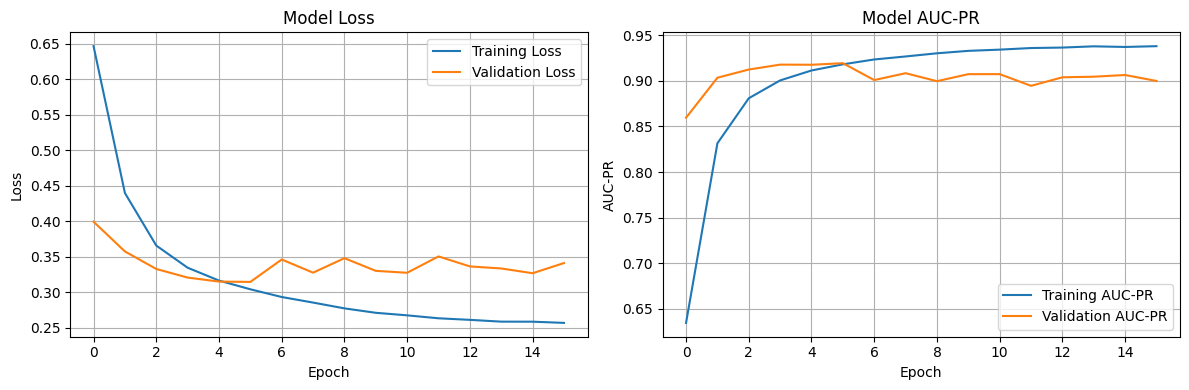

              precision    recall  f1-score   support

Negative (0)       0.86      0.95      0.90     42543
Positive (1)       0.72      0.42      0.53     11704

    accuracy                           0.84     54247
   macro avg       0.79      0.69      0.72     54247
weighted avg       0.83      0.84      0.82     54247

ROC-AUC: 0.9179  |  PR-AUC: 0.7177
{'total_params': 70017, 'latency_ms': 2.5709, 'best_val_loss': 0.3146, 'val_loss_std': 0.0086}


In [14]:
plot_training_curves(history)
metrics_gex = evaluate_classifier(model_gex, X_test, split["test_labels"])
print(get_basic_run_metrics(model_gex, history, X_val[:32]))

In [15]:
# Logistic regression baseline on the same feature set
logreg_gex = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.96      0.75      0.84     42543
         Pos       0.49      0.89      0.63     11704

    accuracy                           0.78     54247
   macro avg       0.73      0.82      0.74     54247
weighted avg       0.86      0.78      0.80     54247

ROC AUC: 0.8762  |  AUPR: 0.6001


---
## 6. Model 2: TCR Beta + Peptide  (TCR sequence baseline)

128-dim TCR-beta AE embedding concatenated with 64-dim peptide AE embedding.

In [16]:
X_train, X_val, X_test = assemble_features(
    (emb_tcr_train, emb_tcr_val, emb_tcr_test),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(f"Input dim: {X_train.shape[1]}")

Input dim: 192


In [17]:
model_tcr = build_residual_mlp(X_train.shape[1], name="tcr_beta_pep")
history = compile_and_train(
    model_tcr, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-3, batch_size=128, epochs=75, patience=10,
)

Epoch 1/75
1457/1457 [==============================] - 17s 10ms/step - loss: 0.6104 - accuracy: 0.8924 - precision: 0.7851 - recall: 0.8027 - auc_roc: 0.9407 - auc_pr: 0.8746 - val_loss: 0.4553 - val_accuracy: 0.9200 - val_precision: 0.8257 - val_recall: 0.8747 - val_auc_roc: 0.9625 - val_auc_pr: 0.9175 - lr: 0.0010
Epoch 2/75
1457/1457 [==============================] - 15s 10ms/step - loss: 0.3738 - accuracy: 0.9223 - precision: 0.8422 - recall: 0.8598 - auc_roc: 0.9638 - auc_pr: 0.9251 - val_loss: 0.6382 - val_accuracy: 0.8187 - val_precision: 0.7478 - val_recall: 0.4487 - val_auc_roc: 0.9048 - val_auc_pr: 0.7496 - lr: 0.0010
Epoch 3/75
1457/1457 [==============================] - 14s 10ms/step - loss: 0.2991 - accuracy: 0.9266 - precision: 0.8459 - recall: 0.8748 - auc_roc: 0.9659 - auc_pr: 0.9296 - val_loss: 0.2766 - val_accuracy: 0.9321 - val_precision: 0.8496 - val_recall: 0.8950 - val_auc_roc: 0.9695 - val_auc_pr: 0.9379 - lr: 0.0010
Epoch 4/75
1457/1457 [=====================

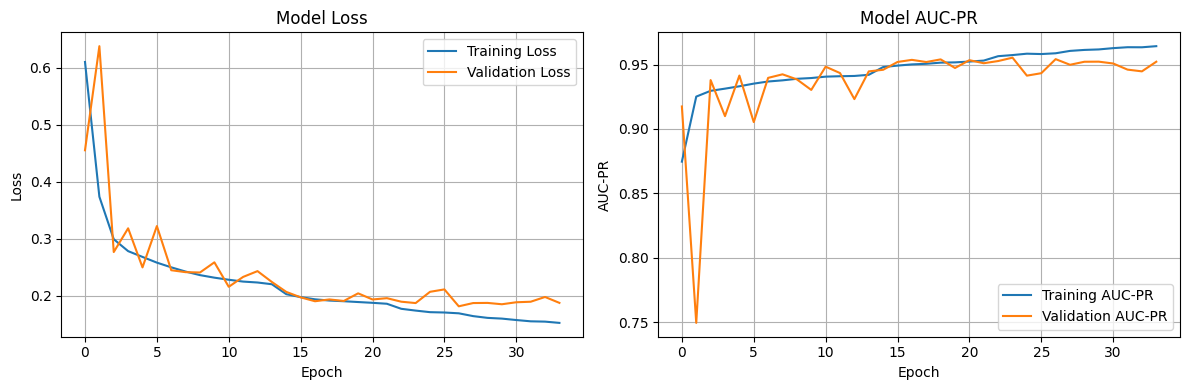

              precision    recall  f1-score   support

Negative (0)       0.89      0.94      0.91     42543
Positive (1)       0.72      0.58      0.65     11704

    accuracy                           0.86     54247
   macro avg       0.81      0.76      0.78     54247
weighted avg       0.86      0.86      0.86     54247

ROC-AUC: 0.9063  |  PR-AUC: 0.6696
{'total_params': 606721, 'latency_ms': 4.0392, 'best_val_loss': 0.1813, 'val_loss_std': 0.0093}


In [18]:
plot_training_curves(history)
metrics_tcr = evaluate_classifier(model_tcr, X_test, split["test_labels"])
print(get_basic_run_metrics(model_tcr, history, X_val[:32]))

In [19]:
logreg_tcr = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.96      0.75      0.84     42543
         Pos       0.49      0.89      0.63     11704

    accuracy                           0.78     54247
   macro avg       0.73      0.82      0.74     54247
weighted avg       0.86      0.78      0.80     54247

ROC AUC: 0.8762  |  AUPR: 0.6001


---
## 7. Model 3: ED Batch GEX → TCR Beta + Peptide  (integration method)

An encoder-decoder (ED) model maps batch-corrected GEX to TCR-beta PE embeddings.
Its latent space (128-dim) serves as the GEX-TCR integrated representation, which is
then concatenated with the peptide AE embedding for downstream prediction.

Set `USE_VJ = True` in Section 1 to additionally include V/J gene spectral embeddings.

In [20]:
# Build and fit the ED integration model (cached after first run)
bgex_train = batch_gex.iloc[train_indices].values.astype("float32")
bgex_val   = batch_gex.iloc[val_indices].values.astype("float32")
bgex_test  = batch_gex.iloc[test_indices].values.astype("float32")

ed_paths = get_ed_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="beta")
print("ED beta — ", end="")

ed_model = build_ed_integration_model(
    input_dim=bgex_train.shape[1],
    output_dim=emb_tcr_train.shape[1],
)
ed_train, ed_val, ed_test = fit_ed_per_split(
    ed_model,
    bgex_train, emb_tcr_train,
    bgex_val,   emb_tcr_val,
    bgex_test,  emb_tcr_test,
    save_paths=ed_paths,
)
print(f"latent shape: {ed_train.shape}")

ED beta —   Loading cached ED embeddings from ED_integration_batch_gex_tcr_embeddings_tcr_split_1.npy...
latent shape: (186493, 128)


In [21]:
# Assemble features — VJ genes are included only when USE_VJ = True
if USE_VJ:
    X_train, X_val, X_test = assemble_features(
        (ed_train, ed_val, ed_test),
        (vj_genes.iloc[train_indices], vj_genes.iloc[val_indices], vj_genes.iloc[test_indices]),
        (emb_pep_train, emb_pep_val, emb_pep_test),
    )
else:
    X_train, X_val, X_test = assemble_features(
        (ed_train, ed_val, ed_test),
        (emb_pep_train, emb_pep_val, emb_pep_test),
    )
print(f"Input dim: {X_train.shape[1]}  (USE_VJ={USE_VJ})")

Input dim: 192  (USE_VJ=False)


In [22]:
model_ed = build_residual_mlp(X_train.shape[1], name="ed_beta_pep")
history = compile_and_train(
    model_ed, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-4, batch_size=128, epochs=75, patience=10,
)

Epoch 1/75
1457/1457 [==============================] - 18s 11ms/step - loss: 0.8109 - accuracy: 0.8428 - precision: 0.6597 - recall: 0.8071 - auc_roc: 0.9077 - auc_pr: 0.8040 - val_loss: 0.9371 - val_accuracy: 0.7983 - val_precision: 0.6839 - val_recall: 0.4057 - val_auc_roc: 0.7680 - val_auc_pr: 0.5143 - lr: 1.0000e-04
Epoch 2/75
1457/1457 [==============================] - 15s 10ms/step - loss: 0.6403 - accuracy: 0.9081 - precision: 0.8388 - recall: 0.7966 - auc_roc: 0.9546 - auc_pr: 0.9008 - val_loss: 0.9225 - val_accuracy: 0.7983 - val_precision: 0.6837 - val_recall: 0.4057 - val_auc_roc: 0.7782 - val_auc_pr: 0.5328 - lr: 1.0000e-04
Epoch 3/75
1457/1457 [==============================] - 15s 11ms/step - loss: 0.5915 - accuracy: 0.9129 - precision: 0.8472 - recall: 0.8083 - auc_roc: 0.9610 - auc_pr: 0.9128 - val_loss: 0.9031 - val_accuracy: 0.7980 - val_precision: 0.6828 - val_recall: 0.4056 - val_auc_roc: 0.7987 - val_auc_pr: 0.5653 - lr: 1.0000e-04
Epoch 4/75
1457/1457 [=========

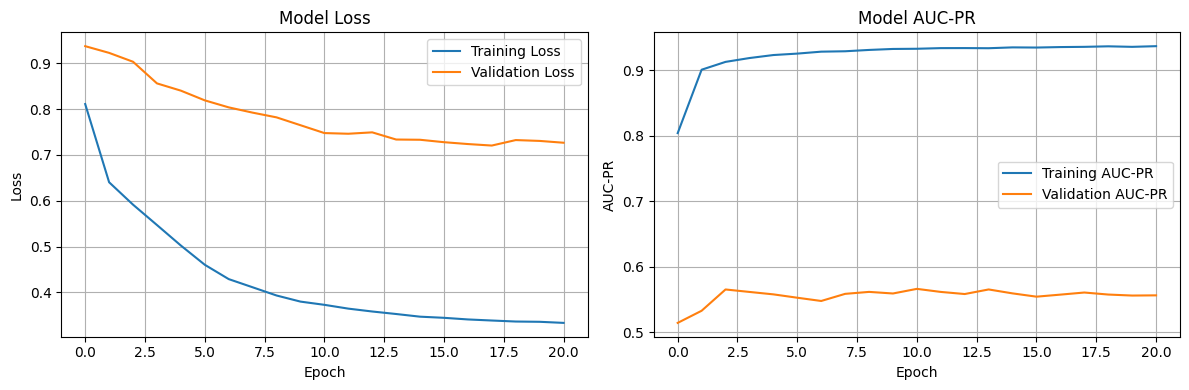

              precision    recall  f1-score   support

Negative (0)       0.95      0.94      0.95     42543
Positive (1)       0.79      0.81      0.80     11704

    accuracy                           0.91     54247
   macro avg       0.87      0.88      0.87     54247
weighted avg       0.92      0.91      0.91     54247

ROC-AUC: 0.9566  |  PR-AUC: 0.8633
{'total_params': 606721, 'latency_ms': 3.5789, 'best_val_loss': 0.7204, 'val_loss_std': 0.0087}


In [23]:
plot_training_curves(history)
metrics_ed = evaluate_classifier(model_ed, X_test, split["test_labels"])
print(get_basic_run_metrics(model_ed, history, X_val[:32]))

In [24]:
logreg_ed = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.97      0.80      0.88     42543
         Pos       0.55      0.91      0.69     11704

    accuracy                           0.82     54247
   macro avg       0.76      0.85      0.78     54247
weighted avg       0.88      0.82      0.83     54247

ROC AUC: 0.9142  |  AUPR: 0.6992


---
## 9. Model 4: mvTCR + Peptide

Loads pre-computed mvTCR latent embeddings (generated by the mvTCR tool) and concatenates them with peptide AE embeddings.

In [8]:
train_input_mvTCR = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_train_indices_{SPLIT_TYPE}_{RUN}.csv")
val_input_mvTCR   = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_val_indices_{SPLIT_TYPE}_{RUN}.csv")
test_input_mvTCR  = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_test_indices_{SPLIT_TYPE}_{RUN}.csv")

X_train, X_val, X_test = assemble_features(
    (train_input_mvTCR.values, val_input_mvTCR.values, test_input_mvTCR.values),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(X_train.shape, X_val.shape, X_test.shape)

(186493, 109) (46624, 109) (54247, 109)


In [ ]:
model_mvtcr = build_residual_mlp(X_train.shape[1], name="mvtcr_pep")
history = compile_and_train(
    model_mvtcr, X_train, split["train_labels"],
    X_val,  split["val_labels"],
    epochs=60,
)

Epoch 1/60


2026-06-10 12:27:01.385973: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1457/1457 [==============================] - 16s 10ms/step - loss: 0.9413 - accuracy: 0.7407 - precision: 0.4980 - recall: 0.6462 - auc_roc: 0.7898 - auc_pr: 0.5362 - val_loss: 0.8040 - val_accuracy: 0.8041 - val_precision: 0.6057 - val_recall: 0.6894 - val_auc_roc: 0.8569 - val_auc_pr: 0.6172 - lr: 1.0000e-04
Epoch 2/60
1457/1457 [==============================] - 14s 9ms/step - loss: 0.8093 - accuracy: 0.7950 - precision: 0.6183 - recall: 0.5367 - auc_roc: 0.8396 - auc_pr: 0.6077 - val_loss: 0.7677 - val_accuracy: 0.8016 - val_precision: 0.6678 - val_recall: 0.4596 - val_auc_roc: 0.8597 - val_auc_pr: 0.6279 - lr: 1.0000e-04
Epoch 3/60
1457/1457 [==============================] - 14s 9ms/step - loss: 0.7569 - accuracy: 0.8111 - precision: 0.6719 - recall: 0.5234 - auc_roc: 0.8571 - auc_pr: 0.6498 - val_loss: 0.7502 - val_accuracy: 0.7914 - val_precision: 0.6609 - val_recall: 0.3930 - val_auc_roc: 0.8540 - val_auc_pr: 0.6175 - lr: 1.0000e-04
Epoch 4/60
1457/1457 [======================

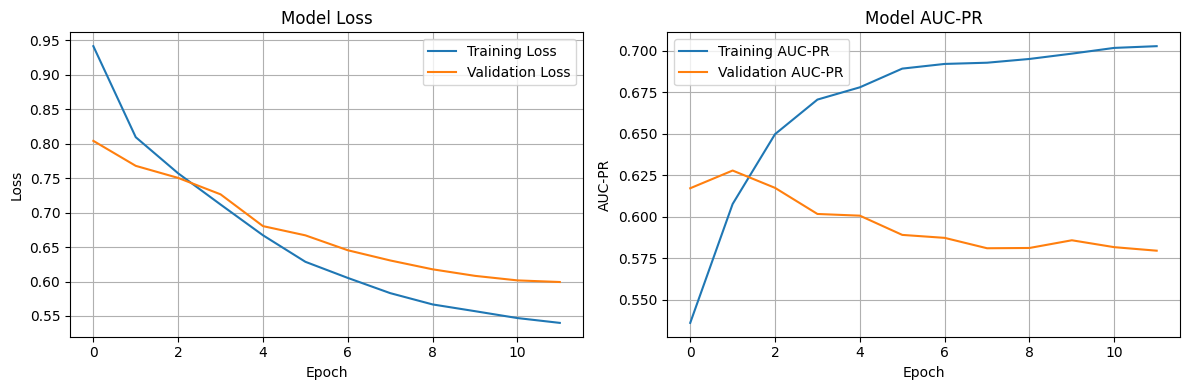

              precision    recall  f1-score   support

Negative (0)       0.90      0.90      0.90     42543
Positive (1)       0.64      0.62      0.63     11704

    accuracy                           0.84     54247
   macro avg       0.77      0.76      0.76     54247
weighted avg       0.84      0.84      0.84     54247

ROC-AUC: 0.8879  |  PR-AUC: 0.6478
{'total_params': 564225, 'latency_ms': 4.0259, 'best_val_loss': 0.5993, 'val_loss_std': 0.0501}


In [10]:
plot_training_curves(history)
metrics_mvtcr = evaluate_classifier(model_mvtcr, X_test, split["test_labels"])
print(get_basic_run_metrics(model_mvtcr, history, X_val[:32]))

In [11]:
logreg_mvtcr = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.97      0.68      0.80     42543
         Pos       0.44      0.93      0.60     11704

    accuracy                           0.73     54247
   macro avg       0.71      0.80      0.70     54247
weighted avg       0.86      0.73      0.76     54247

ROC AUC: 0.8839  |  AUPR: 0.6609


---
## 10. Model 5: Tessa + Peptide

Loads pre-computed Tessa TCR embeddings (generated by `Tessa_main.py`) and concatenates them with peptide AE embeddings.

In [12]:
train_input_Tessa = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_train_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=['contig_id'])
val_input_Tessa   = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_val_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=['contig_id'])
test_input_Tessa  = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_test_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=['contig_id'])

X_train, X_val, X_test = assemble_features(
    (train_input_Tessa.values, val_input_Tessa.values, test_input_Tessa.values),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(X_train.shape, X_val.shape, X_test.shape)

(186493, 94) (46624, 94) (54247, 94)


In [13]:
model_tessa = build_residual_mlp(X_train.shape[1], name="tessa_pep")
history = compile_and_train(
    model_tessa, X_train, split["train_labels"],
    X_val,  split["val_labels"],
    epochs=60,
)

Epoch 1/60
1457/1457 [==============================] - 16s 10ms/step - loss: 0.8824 - accuracy: 0.7842 - precision: 0.5611 - recall: 0.7502 - auc_roc: 0.8438 - auc_pr: 0.6419 - val_loss: 0.6523 - val_accuracy: 0.8942 - val_precision: 0.7678 - val_recall: 0.8454 - val_auc_roc: 0.9377 - val_auc_pr: 0.8688 - lr: 1.0000e-04
Epoch 2/60
1457/1457 [==============================] - 14s 10ms/step - loss: 0.6682 - accuracy: 0.8849 - precision: 0.7847 - recall: 0.7630 - auc_roc: 0.9261 - auc_pr: 0.8493 - val_loss: 0.5956 - val_accuracy: 0.9128 - val_precision: 0.8244 - val_recall: 0.8412 - val_auc_roc: 0.9546 - val_auc_pr: 0.9056 - lr: 1.0000e-04
Epoch 3/60
1457/1457 [==============================] - 15s 10ms/step - loss: 0.5989 - accuracy: 0.9027 - precision: 0.8225 - recall: 0.7940 - auc_roc: 0.9461 - auc_pr: 0.8907 - val_loss: 0.5625 - val_accuracy: 0.9176 - val_precision: 0.8219 - val_recall: 0.8686 - val_auc_roc: 0.9577 - val_auc_pr: 0.9093 - lr: 1.0000e-04
Epoch 4/60
1457/1457 [=========

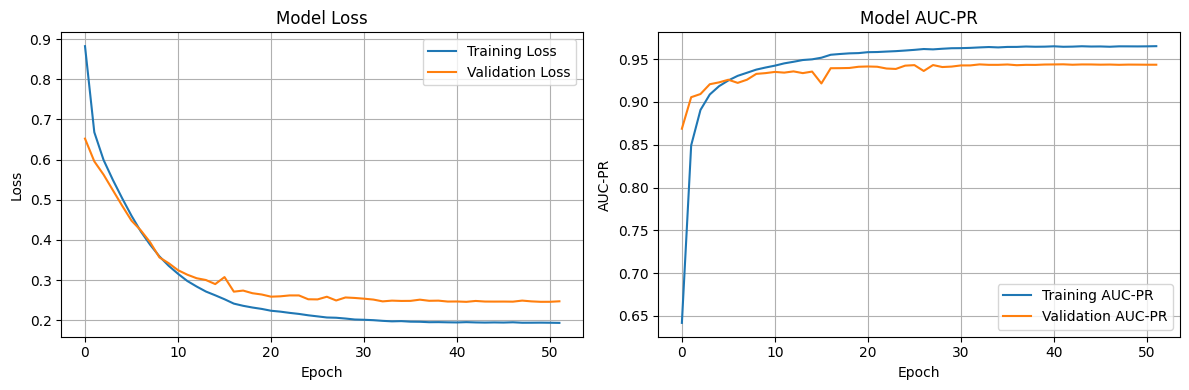

              precision    recall  f1-score   support

Negative (0)       0.90      0.94      0.92     42543
Positive (1)       0.74      0.60      0.66     11704

    accuracy                           0.87     54247
   macro avg       0.82      0.77      0.79     54247
weighted avg       0.86      0.87      0.86     54247

ROC-AUC: 0.9019  |  PR-AUC: 0.6941
{'total_params': 556545, 'latency_ms': 3.353, 'best_val_loss': 0.2461, 'val_loss_std': 0.0009}


In [14]:
plot_training_curves(history)
metrics_tessa = evaluate_classifier(model_tessa, X_test, split["test_labels"])
print(get_basic_run_metrics(model_tessa, history, X_val[:32]))

In [15]:
logreg_tessa = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.96      0.78      0.86     42543
         Pos       0.52      0.87      0.65     11704

    accuracy                           0.80     54247
   macro avg       0.74      0.83      0.76     54247
weighted avg       0.86      0.80      0.82     54247

ROC AUC: 0.8747  |  AUPR: 0.6082


---
## 11. Summary

In [ ]:
vj_tag = "+VJ" if USE_VJ else ""
results = {
    "Batch GEX + Peptide":                  metrics_gex,
    "TCR Beta + Peptide":                   metrics_tcr,
    f"ED GEX→TCR Beta{vj_tag} + Peptide":  metrics_ed,
    "mvTCR + Peptide":                      metrics_mvtcr,
    "Tessa + Peptide":                      metrics_tessa,
}
for name, m in results.items():
    print(f"{name:40s}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}")